In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import pandas as pd

Scrubbing every 2 days with t = 7 may bring us to 1e-11 uncorrectable bits. Achieved 2.35936e-19 1/bit/s

In [ ]:
#  Knowns
mission_lifetime = 2            # years
word_size = 512 + 69            # bytes
total_memory = 2 * 42 * 1e9     # bytes
spenvis_rate = 6e-12            # errors per bit per second


#  Parameters
scrubbing_frequency = 5         # days
memory_fraction = 0.01
total_memory *= memory_fraction  # Use only a fraction of the total memory for the simulation

num_words = int(total_memory / word_size)
t = scrubbing_frequency * 24 * 3600 
lam = spenvis_rate * 8 * word_size * t # errors per word per scrubbing period
n_scrub = int(mission_lifetime * 365 / scrubbing_frequency)
uncorrectables = 0
errors = np.zeros(num_words)
errors_nombu = np.zeros(num_words)

batch_size = 10_000
runs = 50
write = True
cycles = trange(runs, desc="Simulating runs")
for run in cycles:
    errors.fill(0)
    errors_nombu.fill(0)
    uncorrectables = 0

    for n in range(n_scrub):
        for start in range(0, num_words, batch_size):
            end = min(start + batch_size, num_words)
            k = np.random.poisson(lam, end - start)
            errors_nombu[start:end] += k

            extra = np.random.choice([0,1,2], size=(end-start, k.max()), p=[0.8,0.15,0.05])
            mask = np.arange(k.max()) < k[:, None]
            k += (extra * mask).sum(axis=1)

            uncorrectables += np.sum(k > 2)
            errors[start:end] += k

    # After each run, display the summary neatly
    generated_rate = np.sum(errors_nombu) / (total_memory * 8 * mission_lifetime * 365 * 24 * 3600)
    fails_bit = uncorrectables / (total_memory * 8)
    
    # Make sure that the generated rate is correct and in case exit the cycle, using assert
    assert np.abs(generated_rate - spenvis_rate) < 1e-12, f"Generated rate {generated_rate:.5e} deviates from expected {spenvis_rate:.5e}"

    # Postfix the uncorretable rate to the tqdm progress bar
    cycles.set_postfix({"U.R. (per bit per second)": f"{fails_bit/(mission_lifetime * 365 * 24 * 3600):.5e}"})

    # Save errors, errors_nombu, generated_rate, uncorrectables, fails_bit on the runs_jack.csv file
    if write:
        with open("runs_jack.csv", "a") as f:
            f.write(f"\n{np.sum(errors)},{generated_rate:.5e},{uncorrectables},{fails_bit:.5e}")



Simulating runs:   0%|          | 0/50 [00:00<?, ?it/s]

Simulating runs:  84%|████████▍ | 42/50 [09:15<01:45, 13.21s/it, U.R. (per bit per second)=3.11256e-13]


AssertionError: Generated rate 6.01287e-12 deviates from expected 6.00000e-12

In [5]:
fail_bit_second = uncorrectables / (total_memory * 8 * mission_lifetime * 365 * 24 * 3600)
print(f"Uncorrectable rate per bit per second: {fail_bit_second:.5e}")

Uncorrectable rate per bit per second: 3.09107e-13


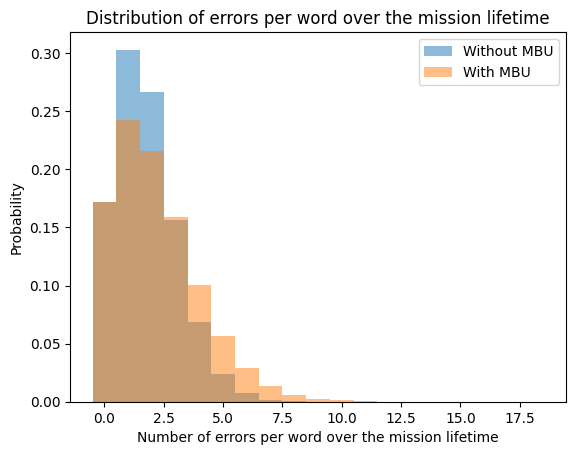

In [4]:
# Plotting distribution of errors per word with an histogram
plt.hist(errors_nombu, bins=np.arange(-0.5, int(np.max(errors_nombu)) + 0.5), density=True, alpha=0.5, label='Without MBU')
plt.hist(errors, bins=np.arange(-0.5, int(np.max(errors)) + 0.5), density=True, alpha=0.5, label='With MBU')
plt.xlabel('Number of errors per word over the mission lifetime')
plt.ylabel('Probability')
plt.title('Distribution of errors per word over the mission lifetime')
plt.legend()
plt.show()

# Data Post Processing

### Dataset Merge

In [14]:
# Merge data from runs_jack.csv and runs_emil.csv into runs_data.csv
runs = pd.read_csv("runs_data.csv")
jack_runs = pd.read_csv("runs_jack.csv")
emil_runs = pd.read_csv("runs_emil.csv")
runs = pd.concat([runs, emil_runs, jack_runs])
pd.DataFrame.to_csv(runs, "runs_data.csv", index=False)

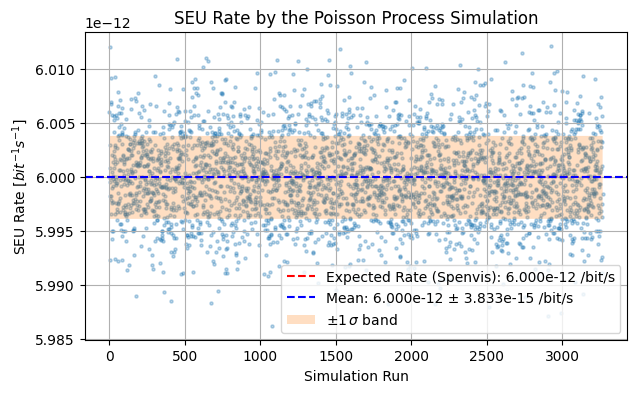

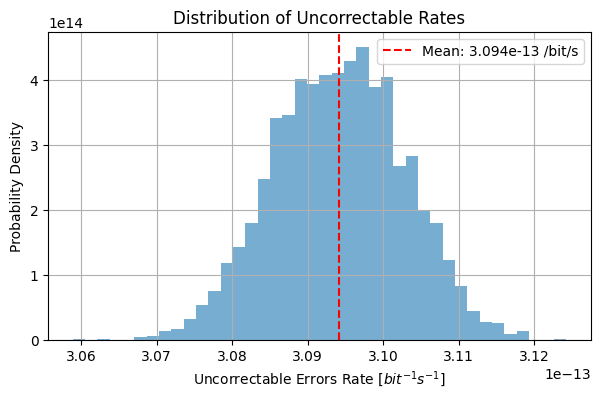

In [32]:
runs = pd.read_csv("runs_emil.csv")
spenvis_rate = 6e-12

# Generated SEU rate doublecheck
plt.figure(figsize=(7,4))
plt.scatter(runs.index, runs['generated_rate'], alpha=0.3, s=5)
plt.axhline(spenvis_rate, color='red', linestyle='--',label=rf'Expected Rate (Spenvis): {spenvis_rate:.3e} /bit/s')
mean = runs["generated_rate"].mean()
std = runs["generated_rate"].std()
plt.axhline(mean, color='blue', linestyle='--', label=f'Mean: {mean:.3e} ± {std:.3e} /bit/s')
plt.fill_between(runs.index, mean-std, mean+std, alpha=0.25, label=r'$\pm1\,\sigma$ band')
plt.xlabel("Simulation Run")
plt.ylabel(r"SEU Rate [$bit^{-1}s^{-1}$]")
plt.title("SEU Rate by the Poisson Process Simulation")
plt.grid()
plt.legend()
plt.show()

# Uncorrectables rate prediction
plt.figure(figsize=(7,4))
unc_rate = runs['fails_bit'] / (mission_lifetime * 365 * 24 * 3600)
plt.hist(unc_rate, bins=40, density=True, alpha=0.6)
plt.axvline(unc_rate.mean(), color='red', linestyle='--', label=f'Mean: {unc_rate.mean():.3e} /bit/s')
plt.xlabel(r"Uncorrectable Errors Rate [$bit^{-1}s^{-1}$]")
plt.ylabel("Probability Density")
plt.title("Distribution of Uncorrectable Rates")
plt.legend()
plt.grid()
plt.show()